In [1]:
import numpy as np
from pyscf import gto, scf, cc

####  test H2 monomers ####
a = 2 # bond length in a cluster
d = 4 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
unit = 'B'
basis = 'sto6g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis="sto6g",
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-35-generic', version='#35~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May 26 19:30:42 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Tue Jun  9 14:49:22 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 2
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

(np.float64(-0.039641400884833235),
 array([[-5.66005116e-16]]),
 array([[[[-0.19736585]]]]))

In [2]:
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-5)


Preparing AFQMC calculation
Calculating Cholesky integrals
Cholesky shape: (3, 2, 2) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [1, 1]
Number of basis functions:  2
Number of Cholesky vectors: 3


In [2]:
import h5py
from jax import numpy as jnp
from afqmc import cholesky, propagation
from afqmc.wavefunctions import wfn_exp

# def load_afqmc(options=None,
#                amp_file="amplitudes.npz",
#                chol_file="FCIDUMP_chol"):

#     options["dt"] = options.get("dt", 0.005)
#     options["eql_time"] = options.get("eql_time", 20)
#     options["n_walkers"] = options.get("n_walkers", 50)
#     options["n_prop_steps"] = options.get("n_prop_steps", 50)
#     options["n_blocks"] = options.get("n_blocks", 500)
#     options["seed"] = options.get("seed", np.random.randint(1, int(1e6)))
#     options["n_exp_terms"] = options.get("n_exp_terms",6)
#     options["walker_type"] = options.get("walker_type", "rhf")
#     options["trial"] = options.get("trial", None)
#     options["free_projection"] = options.get("free_projection", False)
#     options["n_batch"] = options.get("n_batch", 1)
#     options["max_error"] = options.get("max_error", 0.0)
#     options["nchol_chunk"] = options.get("nchol_chunk", 100)
#     options["max_memory"] = options.get("max_memory", 2000) # MB
#     options["mix_precision"] = options.get("mix_precision", True)

#     print("\nLoad system from Integral File")

#     with h5py.File(chol_file, "r") as fh5:
#         [nelec, norb, ms] = fh5["header"]
#         spin_type = fh5["spin_type"][()]
#         h0 = jnp.array(fh5.get("energy_core"))
#         h1 = jnp.array(fh5.get("hcore"))
#         chol = jnp.array(fh5.get("chol"))
#         h1_mod = jnp.array(fh5.get("hcore_mod"))
    
#     if isinstance(spin_type, bytes):
#         spin_type = spin_type.decode()

#     assert spin_type in ["restricted", "unrestricted"]

#     if spin_type == 'restricted':
#         h1 = jnp.array(h1).reshape(norb, norb)
#         h1_mod = jnp.array(h1_mod).reshape(norb, norb)
#         chol = jnp.array(chol).reshape(-1, norb, norb)

#     elif spin_type == 'unrestricted':
#         h1 = jnp.array(h1).reshape(2, norb, norb)
#         h1_mod = jnp.array(h1_mod).reshape(2, norb, norb)
#         chol = jnp.array(chol).reshape(2, -1, norb, norb)

#     assert type(ms) is np.int64
#     assert type(nelec) is np.int64
#     assert type(norb) is np.int64

#     ms, nelec, norb = int(ms), int(nelec), int(norb)
#     nelec_sp = ((nelec + abs(ms)) // 2, (nelec - abs(ms)) // 2)

#     ham_data = {}
#     ham_data["h0"] = h0

#     if spin_type == 'restricted':
#         ham_data["h1"] = jnp.array([h1, h1])
#         ham_data["h1_mod"] = jnp.array(h1_mod)
#         nchol = chol.shape[0]
#         ham_data["chol"] = jnp.array(chol.reshape(chol.shape[0], -1))
#     elif spin_type == 'unrestricted':
#         ham_data["h1"] = jnp.array(h1)
#         ham_data["h1_mod"] = jnp.array(h1_mod)
#         nchol = chol[0].shape[0]
#         ham_data["chol"] = jnp.array([chol[0].reshape(chol[0].shape[0], -1),
#                                       chol[1].reshape(chol[1].shape[0], -1)])
#         # ham_data["chol"] = [jnp.array(chol[0]), jnp.array(chol[1])]

#     options["nchol_chunk"] = cholesky.chunk_chol(
#         chol, options["nchol_chunk"], options["max_memory"]/options["n_walkers"])

#     wave_data = {}
#     mo_coeff = jnp.array([np.eye(norb),np.eye(norb)])

#     if spin_type == "restricted":
#         nocc = nelec_sp[0]
#         wave_data["mo_coeff"] = mo_coeff[0][:,:nocc]
#         wave_data["nelec"] = nelec_sp
#         wave_data["norb"] = norb
#         wave_data["nchol"] = nchol
#         wave_data["rdm1"] = jnp.array([wave_data["mo_coeff"] @ wave_data["mo_coeff"].T] * 2)
#         amplitudes = np.load(amp_file)
#         t1 = jnp.array(amplitudes["t1"])
#         t2 = jnp.array(amplitudes["t2"])
#         ci2 = t2 + jnp.einsum("ia,jb->iajb", t1, t1)
#         wave_data["ci1"] = t1
#         wave_data["ci2"] = ci2
        
#     print("\nQMC System")
#     print(f"Number of electrons: {nelec_sp}")
#     print(f"Spin Multiplicity:   {ms}")
#     print(f"Number of orbitals:  {norb}")
#     print(f"Number of Chol:      {nchol}")

#     print("\nQMC Parameters")
#     for op in options:
#         if options[op] is not None:
#             print(f"{str(op):<20s}: {str(options[op]):>20s}")

#     return ham_data, wave_data, options

In [3]:
from afqmc import prep

options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'trial': 'pt2ccsd',
            }

ham_data, ham, prop, trial, wave_data, sampler, options = (prep.init_afqmc())


Load system from Integral File


Maximum memory per walker:            6.67 MB
Maximum number of Cholesky per chunk: 109226
Number of Cholesky chunks:            1
Number of Cholesky per chunk:         3
Number of padding Cholesky:           0

QMC System
Number of electrons: (1, 1)
Spin Multiplicity:   0
Number of orbitals:  2
Number of Chol:      3

QMC Parameters
eql_time            :                   10
n_blocks            :                  100
n_walkers           :                  300
max_error           :                  0.0
mix_precision       :                False
seed                :                   17
walker_type         :                  rhf
trial               :              pt2ccsd
dt                  :                0.005
n_exp_terms         :                    6
n_prop_steps        :                   50
save_walkers        :                False
free_projection     :                False
n_batch             :                    1
nchol_chunk         :                    3
max_memory         

In [4]:
wave_data["ci1"] = wave_data["t1"]
wave_data["ci2"] = wave_data["t2"]

In [ ]:
# from jax import random

# def init_prop_data(
#     trial,
#     wave_data: dict,
#     ham_data: dict,
#     options: dict,
# ) -> dict:
#     prop_data = {}
#     prop_data["n_killed_walkers"] = 0
#     prop_data["key"] = random.PRNGKey(options["seed"])
#     prop_data["weights"] = jnp.ones(options["n_walkers"])
#     prop_data["walkers"] = jnp.array([wave_data["mo_coeff"]]*options["n_walkers"], dtype=jnp.complex128)
#     energies = jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data))
#     guide_olps = trial.calc_overlap(prop_data["walkers"], wave_data)
#     trial_olps = trial.calc_trial_overlap(prop_data["walkers"], wave_data)
#     olp_ratio = trial_olps / guide_olps
#     weights_p = prop_data["weights"] * olp_ratio
#     e_estimate = (jnp.sum(weights_p * energies) / jnp.sum(weights_p)).real
#     prop_data["e_estimate"] = e_estimate
#     prop_data["pop_control_ene_shift"] = e_estimate
#     prop_data["overlaps"] = guide_olps
#     return prop_data

In [5]:
from afqmc.sampling import sampler_exp
from afqmc.wavefunctions import rhf_wfn, rcisd_wfn

prop = propagation.propagator_restricted(
        options["dt"], 
        options["n_walkers"], 
        options["n_exp_terms"],
        options["n_batch"]
    )

wave = wfn_exp.wfn(    
    guide_overlap_fn=rhf_wfn.calc_overlap,
    trial_overlap_fn=rhf_wfn.calc_overlap,
    force_bias_fn=rhf_wfn.calc_force_bias,
    energy_fn=rhf_wfn.calc_energy,
    nelec=trial.nelec,
    norb=trial.norb,
    nchol=sampler.n_chol,
    nchol_chunk=trial.nchol_chunk,
    )

sampler = sampler_exp(
    options["n_prop_steps"],
    options["n_blocks"],
    n_chol=sampler.n_chol,
    )

In [10]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

wave_data["rdm1"] = trial.get_rdm1(wave_data)
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)
prop_data = prep.init_hf_prop_data(trial, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 500

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-35-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Initalize QMC walkers by HF

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430      0.46
 5.00    300.548964      0    300.548964     -1.092692      0.63
10.00    300.623201      0    300.623201     -1.111641      0.81
15.00    300.427687      0    300.427687     -1.087516      0.99
20.00    300.538077      0    300.538077     -1.095305      1.17
25.00    300.446543      0    300.446543     -1.088213      1.35
30.00    300.454100      0    300.454100     -1.093637      1.52
35.00    300.650029      0    300.650029     -1.099966      1.70
40.00    300.462057      0    300.462057     -1.091092      1.88
45.00    300.525236      0    300.525236    

E = -1.093461 +/- 0.000306 Ha  (averaged over 421 blocks, t >= 20)


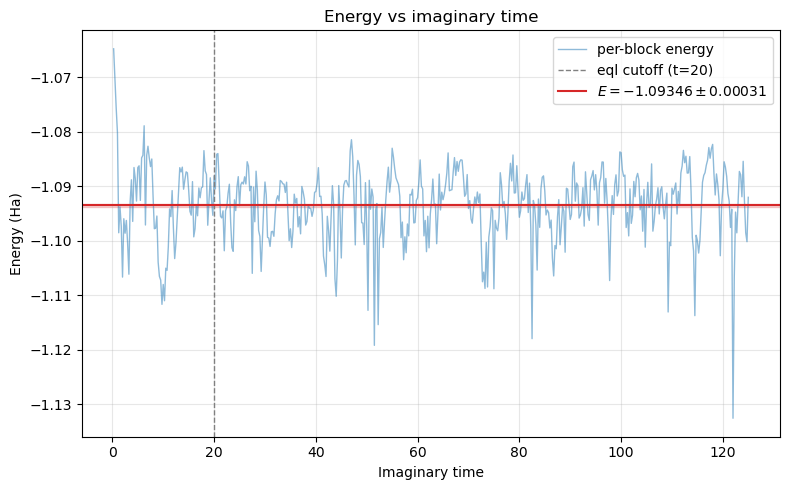

In [11]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
wave_cisd = wfn_exp.wfn(    
    guide_overlap_fn=rcisd_wfn.calc_overlap,
    trial_overlap_fn=rhf_wfn.calc_overlap,
    force_bias_fn=rcisd_wfn.calc_force_bias,
    energy_fn=rhf_wfn.calc_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

AttributeError: module 'afqmc.wavefunctions.rcisd_wfn' has no attribute 'calc_overlap'

In [10]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

# prep.print_start()
config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, rhf_guide_cisd, wave_data)
prop_data = init_prop_data(rhf_guide_cisd, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp2 = np.zeros(neql_block, dtype=np.complex128)
energies2 = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, rhf_guide_cisd, prop_data, ham_data, wave_data)
    
    weightsp2[n-1] = wp
    energies2[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      6.17.0-29-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430      0.54
 5.00    300.609422      0    291.085776     -1.089192      3.21
10.00    300.475967      0    286.107178     -1.106445      3.45
15.00    300.553220      0    290.337214     -1.090839      3.70
20.00    300.569405      0    289.079221     -1.095492      3.94
25.00    300.567180      0    291.348605     -1.088329      4.19
30.00    300.494677      0    289.822873     -1.093513      4.44
35.00    300.693233      0    288.647047     -1.094035      4.69
40.00    300.499442      0    289.416006     -1.089395      4.93
45.00    300.568944      0    288.623209     -1.092207      5.18
50.00   

E = -1.092914 +/- 0.000120 Ha  (averaged over 921 blocks, t >= 20)


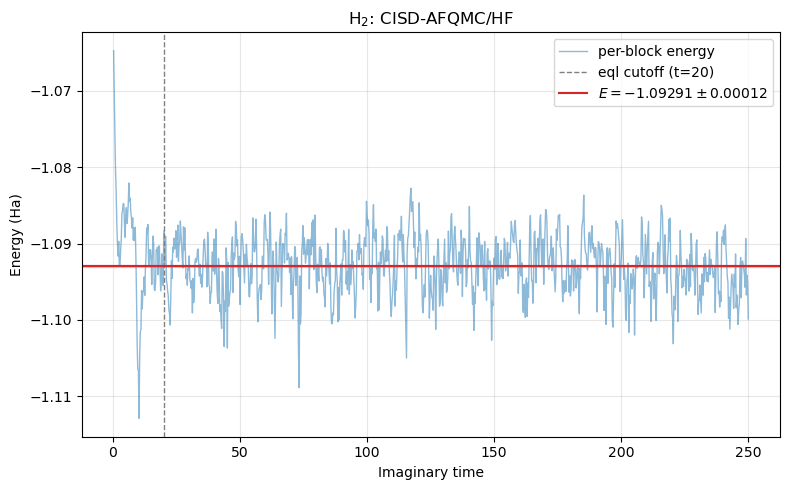

In [11]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w2 = weightsp2[mask].real
e2 = energies2[mask].real
N = len(e2)

# weight-averaged energy
E_mean2 = np.sum(w2 * e2) / np.sum(w2)

# weighted variance (Bessel-corrected) -> std of the mean
wvar2 = np.sum(w2 * (e2 - E_mean2) ** 2) / np.sum(w2) * N / (N - 1)
sem2 = np.sqrt(wvar2 / N)

print(f"E = {E_mean2:.6f} +/- {sem2:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies2.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean2, color="C3", lw=1.5,
            label=fr"$E = {E_mean2:.5f} \pm {sem2:.5f}$")
plt.axhspan(E_mean2 - sem2, E_mean2 + sem2, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

E = -1.093359 +/- 0.000231 Ha  (averaged over 921 blocks, t >= 20)


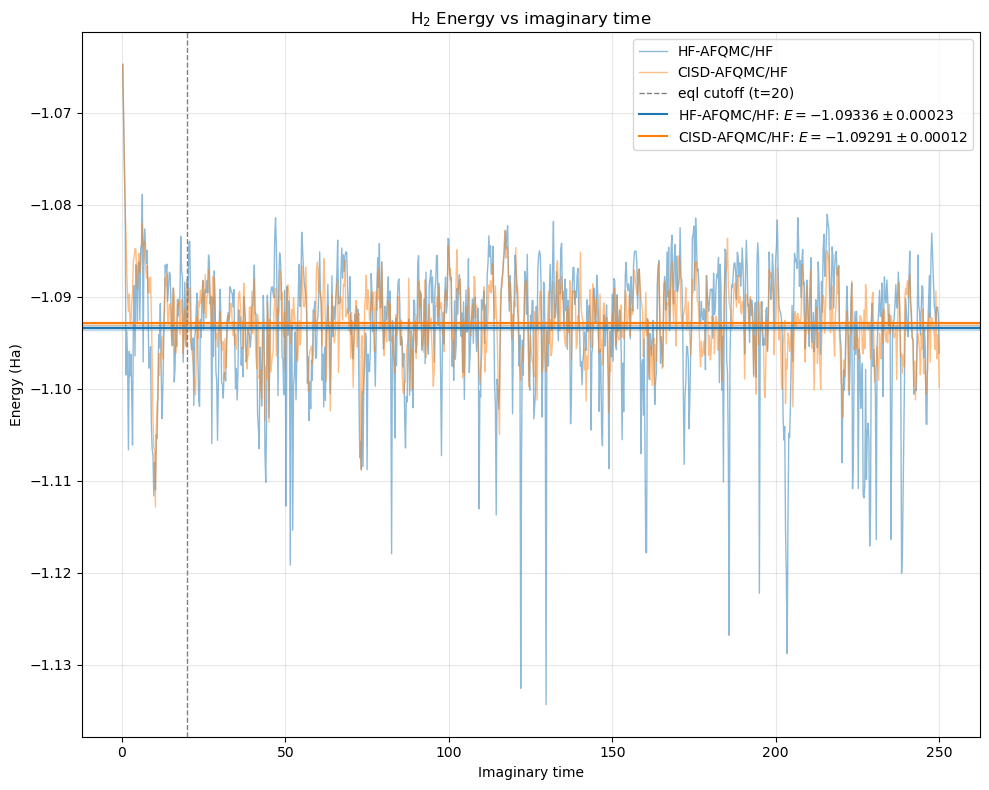

In [13]:
imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(10, 8))
plt.plot(imag_time, energies.real, lw=1, color="C0", alpha=0.5, label="HF-AFQMC/HF")
plt.plot(imag_time, energies2.real, lw=1, color="C1", alpha=0.5, label="CISD-AFQMC/HF")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, lw=1.5, color="C0", label=fr"HF-AFQMC/HF: $E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C0", alpha=0.2)
plt.axhline(E_mean2, lw=1.5, color="C1", label=fr"CISD-AFQMC/HF: $E = {E_mean2:.5f} \pm {sem2:.5f}$")
plt.axhspan(E_mean2 - sem2, E_mean2 + sem2, color="C1",alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$ Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
from afqmc.sampling import sampler_exp
from afqmc.wavefunctions import rhf_wfn, rms_wfn

prop = propagation.propagator_restricted(
        options["dt"], 
        options["n_walkers"], 
        options["n_exp_terms"],
        options["n_batch"]
    )

wave = rwfn_exp.wfn(    
    guide_overlap_fn=rms_wfn.r_overlap,
    force_bias_fn=rms_wfn.r_force_bias,
    trial_overlap_fn=rhf_wfn.r_overlap,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=wave_data["nchol"],
    nchol_chunk=options["nchol_chunk"],
    )

sampler = sampler_exp(
    options["n_prop_steps"],
    options["n_blocks"],
    n_chol=wave_data["nchol"],
    )

In [12]:
import time
import numpy as np
from afqmc import config
from functools import partial

print = partial(print, flush=True)
init_time = time.time()

config.setup_jax()

ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data = init_prop_data(wave, wave_data, ham_data, options)

Hostname:     yichi-thinkpad
System:       Linux
Node:         yichi-thinkpad
Release:      4.4.0-26100-Microsoft
Machine:      x86_64
Processor:    x86_64
JAX backend:  CPU
JAX devices:  [CpuDevice(id=0)]
Device kind:  cpu
Platform:     cpu


KeyError: 'slaters'

In [ ]:
init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print("\nEquilibration")

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp2 = np.zeros(neql_block, dtype=np.complex128)
energies2 = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, rhf_guide_cisd, prop_data, ham_data, wave_data)
    
    weightsp2[n-1] = wp
    energies2[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")

In [ ]:
from afqmc import prep
import opt_einsum as oe
from jax import vmap

def get_stocc(mo_t1, tau, nslater, key):
    key, subkey = random.split(key)
    
    fieldy = random.normal(
        subkey,
        shape=(nslater, tau.shape[0],)
        )
    # ytaus shape (nslater, nocc, nvir)
    ytaus = oe.contract("sg,gia->sia", fieldy, tau, backend='jax')

    slaters = vmap(lambda y: prep.rthouless(mo_t1, y))(ytaus)

    return slaters, key

In [ ]:
from afqmc import prep
stocc, prop_data = prep.get_ccsd_walkers(
    prop_data, wave_data, 10, options["walker_type"]
)
print(stocc.shape)
wave_data["slater"] = stocc

NameError: name 'prop_data' is not defined